## CAR PRICE PREDICTION PROJECT
#### By: Malotse Emanuel Mathipa
#### Dataset : Car Price Prediction
#### Objective: Clean, explore, and prepare vehicle data to build a car price prediction model

In [1]:
# Importation of all the required libraries for clarity and to ensure they are available throughout.

In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import re
import math
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.ticker as ticker

# Section 1a

In [3]:
# loading the car price dataset
# Loading the CSV file into a Pandas DataFrame and display
df = pd.read_csv('Price_prediction.csv')

In [4]:
# A quick preview the first five rows
df

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,NaN,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


In [5]:
# Inspect data types BEFORE conversion
# Identify which columns have incorrect types
# What needs to be fixed before analysis
df.dtypes

ID                    int64
Price                 int64
Levy                 object
Manufacturer         object
Model                object
Prod. year            int64
Category             object
Leather interior     object
Fuel type            object
Engine volume        object
Mileage              object
Cylinders           float64
Gear box type        object
Drive wheels         object
Doors                object
Wheel                object
Color                object
Airbags               int64
dtype: object

In [6]:
# FUNCTION: convert_data_types
# Fix incorrect data types across all relevant columns.
#
# Key issues addressed:
#   - 'Levy'          → Contains '-' as placeholder for missing values.
#                       Strip non-numeric characters, fill with 0, cast to int64.
#   - 'Engine volume' → Contains 'Turbo' suffix. Strip non-numeric chars, cast to float64.
#   - 'Mileage'       → Contains 'km' suffix. Strip, cast to int64.
#   - Categorical cols→ Cast to pandas 'category' dtype for memory efficiency.
#
# Regex pattern '[^0-9]' matches any character that is NOT a digit (0–9),
# replacing it with '' (empty string) or '0' as appropriate.

In [7]:
#Converting datatypes
df['Levy'] = df['Levy'].replace('[^0-9]', int('0'), regex=True).astype('int64') 
#The code contains regex used to remove special characters and to replace them with '0'
df['Manufacturer'] = df['Manufacturer'].astype('category')
df['Model'] = df['Model'].astype('category')
df['Prod. year'] = df['Prod. year'].astype('category')
df['Category'] = df['Category'].astype('category')
df['Leather interior'] = df['Leather interior'].astype('category')
df['Fuel type'] = df['Fuel type'].astype('category')
df['Engine volume'] = df['Engine volume'].replace('[^0-9]', '', regex=True).astype('float64') #Regex is also used here to replace non-float characters
df['Mileage'] = df['Mileage'].replace('[^0-9]', '', regex=True).astype('int64')
df['Gear box type'] = df['Gear box type'].astype('category')
df['Drive wheels'] = df['Drive wheels'].astype('category')
df['Wheel'] = df['Wheel'].astype('category')
df['Doors'] = df['Doors'].astype('category')

In [8]:
df

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,35.0,186005,NaN,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,0,HONDA,FIT,2006,Hatchback,No,Petrol,13.0,200000,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,25.0,168966,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,13.0,91901,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,0,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,20.0,300000,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,24.0,161600,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2.0,116365,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2.0,51258,4.0,Automatic,Front,04-May,Left wheel,Black,4


In [9]:
# Inspect data types AFTER conversion
# Confirms that all columns now carry the correct dtype.
df.dtypes

ID                     int64
Price                  int64
Levy                   int64
Manufacturer        category
Model               category
Prod. year          category
Category            category
Leather interior    category
Fuel type           category
Engine volume        float64
Mileage                int64
Cylinders            float64
Gear box type       category
Drive wheels        category
Doors               category
Wheel               category
Color                 object
Airbags                int64
dtype: object

 ### Observations and Conclusion — Section 1a
Observations:

Prior to conversion, columns like Levy, Engine volume, and Mileage were stored as object (string) dtype, making numeric analysis impossible.
1.Levy used the character '-' as a placeholder for missing values, which prevented numeric casting — handled with regex replacement.
2.Engine volume contained the word 'Turbo' appended to some values — stripped via regex before casting to float64.
3.Mileage contained the suffix 'km' on every value — removed before casting to int64.
4.Columns such as ID and Color were not converted to category as they are either irrelevant identifiers or plain text.
### Conclusion:
From the observations made,columns now carry their correct data types, enabling accurate statistical analysis, visualisation, and machine learning downstream.

# Section 1b

In [10]:
# Check for NaN values in the entire DataFrame,remove or impute them if when found.
df.isna()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
19233,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
19234,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
19235,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
# Count the number of NaN values in each column
df.isna().sum()

ID                   0
Price                0
Levy                 0
Manufacturer         0
Model                0
Prod. year           0
Category             0
Leather interior     0
Fuel type            0
Engine volume        0
Mileage              0
Cylinders           20
Gear box type        0
Drive wheels         0
Doors                0
Wheel                0
Color                0
Airbags              0
dtype: int64

In [12]:
# Dropping the NaN values from the dataframe
df.dropna(inplace = True)

In [13]:
# Confirming if there are still NaN values
df.isna().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [14]:
df['Levy'] = df['Levy'].replace(0, df['Levy'].mean())

## Observations & Conclusion — Section 1b

### Observations:

1.The Cylinders column was the only column containing NaN values — 20 rows were affected.
2.Zero values in Levy originated from the regex replacement in Section 1a (where '-' was replaced with 0). These represent missing levy data, not genuine zero-levy transactions.
### Conclusion:
NaN rows were removed using dropna(). The Levy column zeros were replaced with the column mean to preserve the distribution without distorting the dataset.

# Section 2a

In [15]:
# Handling duplicates and detecte duplicated rows, display them for inspection,and then remove them — keeping the last occurrence.

df.duplicated().sum()

np.int64(313)

In [16]:
# Viewing duplicated rows
df[ df.duplicated() ]

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
425,45815372,7840,632.867149,MERCEDES-BENZ,E 200,1998,Sedan,No,CNG,2.0,180003,4.0,Manual,Rear,04-May,Left wheel,Black,4
1581,45815363,8781,632.867149,TOYOTA,Ist,2002,Hatchback,No,Petrol,15.0,117000,4.0,Automatic,4x4,04-May,Right-hand drive,Red,4
1697,45732125,18503,632.867149,TOYOTA,Prius,2010,Sedan,No,Petrol,18.0,162000,4.0,Automatic,Front,04-May,Left wheel,Grey,12
1972,45507765,20385,632.867149,MERCEDES-BENZ,CLS 500,2005,Sedan,Yes,Petrol,5.0,230000,8.0,Tiptronic,Rear,04-May,Left wheel,Silver,10
2131,45815363,8781,632.867149,TOYOTA,Ist,2002,Hatchback,No,Petrol,15.0,117000,4.0,Automatic,4x4,04-May,Right-hand drive,Red,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18974,45815465,2352,1273.000000,LEXUS,IS 350,2015,Sedan,Yes,Petrol,35.0,80856,6.0,Automatic,4x4,04-May,Left wheel,Black,12
19137,45810466,15125,642.000000,CHEVROLET,Orlando,2012,Jeep,Yes,Diesel,2.0,156834,4.0,Automatic,Front,04-May,Left wheel,Golden,4
19200,45725908,36065,640.000000,MERCEDES-BENZ,CLA 250 AMG,2013,Sedan,Yes,Petrol,20.0,68000,4.0,Tiptronic,Front,04-May,Left wheel,Red,12
19203,45761487,13485,645.000000,TOYOTA,Prius,2011,Sedan,No,Hybrid,18.0,281600,6.0,Automatic,Front,04-May,Left wheel,Grey,8


In [17]:
# FUNCTION: handle_duplicates,and detect duplicate rows, show them for inspection,and then remove them — keeping the last occurrence.

df = df.drop_duplicates(keep='last')
df.shape

(18904, 18)


## Observations & Conclusion — Section 2a
### Observations:

A total of 313 duplicate rows* were identified in the dataset.
### Conclusion:
Duplicates were removed using drop_duplicates(keep='last'), reducing the dataset from 19,237 to 18,924 records. Retaining duplicates would have given some car listings disproportionate influence during model training

# Section 2b

##### Identify and remove the outliers from all numeric columns using the Interquartile Range (IQR) method.

In [18]:
df.describe()

,ID,Price,Levy,Engine volume,Mileage,Cylinders,Airbags
count,1.890400e+04,1.890400e+04,18904.000000,18904.000000,1.890400e+04,18904.000000,18904.000000
mean,4.557567e+07,1.859118e+04,823.921354,17.778248,1.556884e+06,4.579719,6.567711
std,9.370266e+05,1.922369e+05,407.148895,12.263399,4.882799e+07,1.200739,4.322926
min,2.074688e+07,1.000000e+00,87.000000,0.000000,0.000000e+00,1.000000,0.000000
25%,4.569504e+07,5.331000e+03,632.867149,3.000000,7.021400e+04,4.000000,4.000000
50%,4.577191e+07,1.317200e+04,642.000000,18.000000,1.264000e+05,4.000000,6.000000
75%,4.580174e+07,2.210700e+04,917.000000,25.000000,1.891738e+05,4.000000,12.000000
max,4.581665e+07,2.630750e+07,11714.000000,73.000000,2.147484e+09,16.000000,16.000000


In [19]:
df

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
2,45774419,8467,632.867149,HONDA,FIT,2006,Hatchback,No,Petrol,13.0,200000,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862.000000,FORD,Escape,2011,Jeep,Yes,Hybrid,25.0,168966,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446.000000,HONDA,FIT,2014,Hatchback,Yes,Petrol,13.0,91901,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,45802912,39493,891.000000,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2.0,160931,4.0,Automatic,Front,04-May,Left wheel,White,4
6,45656768,1803,761.000000,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,18.0,258909,4.0,Automatic,Front,04-May,Left wheel,White,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,632.867149,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,20.0,300000,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831.000000,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,24.0,161600,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836.000000,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2.0,116365,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288.000000,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2.0,51258,4.0,Automatic,Front,04-May,Left wheel,Black,4


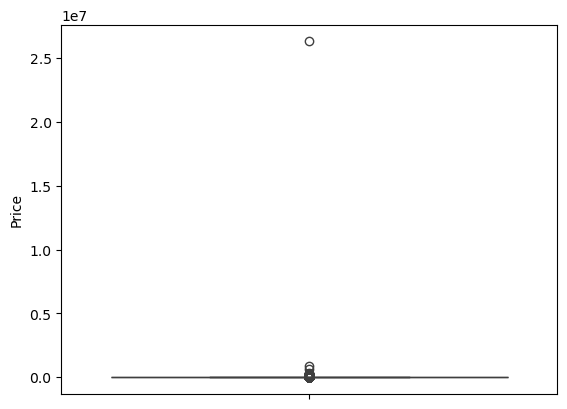

In [20]:
# Create a boxplot to check the presence of outliers,so that they can be removed.

sns.boxplot(y='Price', data=df)
plt.show()

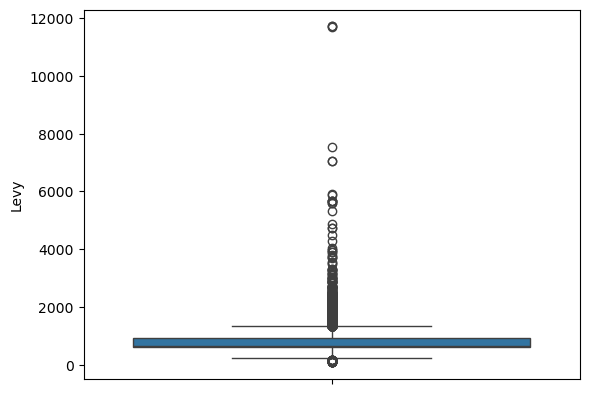

In [21]:
sns.boxplot(y='Levy', data=df)
plt.show()

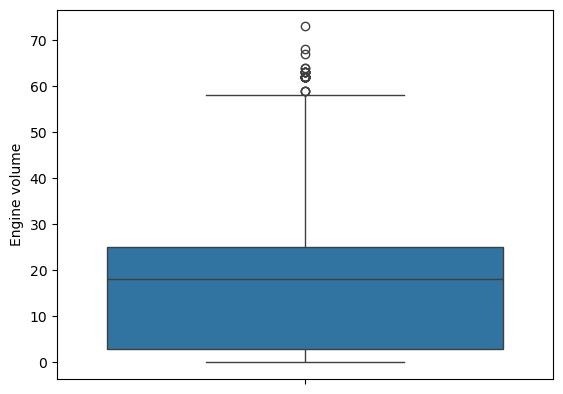

In [22]:
sns.boxplot(y='Engine volume', data=df)
plt.show()

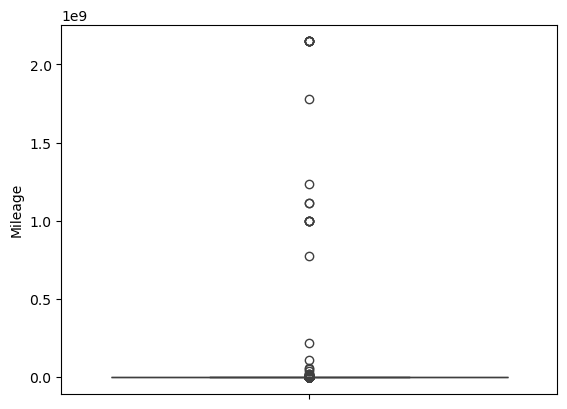

In [23]:
sns.boxplot(y='Mileage', data=df)
plt.show()

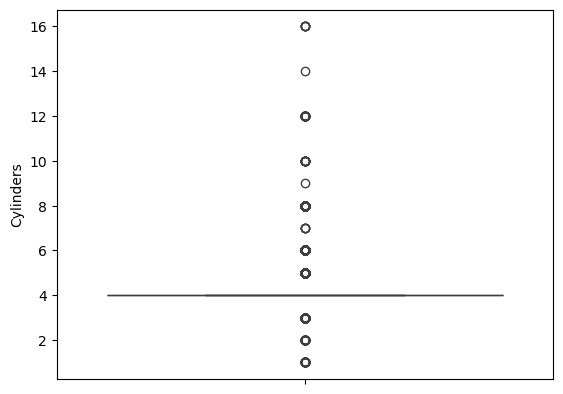

In [24]:
sns.boxplot(y='Cylinders', data=df)
plt.show()

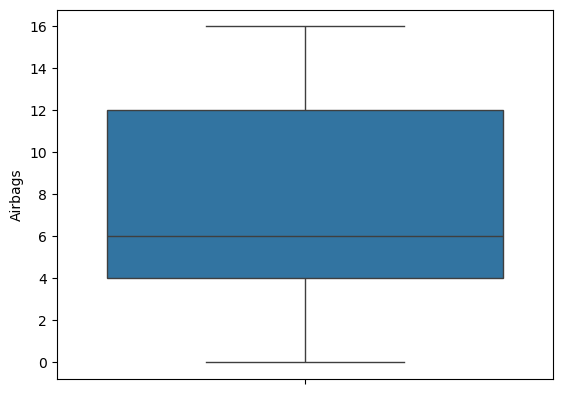

In [25]:
sns.boxplot(y='Airbags', data=df)
plt.show()

In [26]:
q1 = np.quantile(df['Price'], 0.25)
q3 = np.quantile(df['Price'], 0.75)
print(q1,q3)
IQR = q3-q1
IQR
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
print(lower_limit,upper_limit)

5331.0 22107.0
-19833.0 47271.0


In [27]:
index_list = df.index[ (df['Price'] < lower_limit) | (df['Price'] > upper_limit) ]
print(index_list, len(index_list))
df = df.drop(index_list)
print(df.shape)

Index([   14,    36,    47,    56,    73,    90,   111,   127,   189,   211,
       ...
       19062, 19085, 19109, 19111, 19121, 19144, 19161, 19180, 19188, 19211],
      dtype='int64', length=1043) 1043
(17861, 18)


In [28]:
q1 = np.quantile(df['Levy'], 0.25)
q3 = np.quantile(df['Levy'], 0.75)
print(q1,q3)
IQR = q3-q1
IQR
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
print(lower_limit,upper_limit)

632.867148878597 891.0
245.66787219649262 1278.1992766821045


In [29]:
index_list = df.index[ (df['Levy'] < lower_limit) | (df['Levy'] > upper_limit) ]
print(index_list, len(index_list))
df = df.drop(index_list)
print(df.shape)

Index([   18,    19,    26,    29,    30,    33,    37,    39,    44,    78,
       ...
       19116, 19119, 19127, 19145, 19155, 19167, 19186, 19217, 19228, 19235],
      dtype='int64', length=1664) 1664
(16197, 18)


In [30]:
q1 = np.quantile(df['Engine volume'], 0.25)
q3 = np.quantile(df['Engine volume'], 0.75)
print(q1,q3)
IQR = q3-q1
IQR
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
print(lower_limit,upper_limit)

3.0 24.0
-28.5 55.5


In [31]:
index_list = df.index[ (df['Engine volume'] < lower_limit) | (df['Engine volume'] > upper_limit) ]
print(index_list, len(index_list))
df = df.drop(index_list)
print(df.shape)

Index([ 1501,  2599,  2732,  6005,  8082,  9644, 11458, 11717, 13850, 15332,
       16419, 17634, 17734, 18884],
      dtype='int64') 14
(16183, 18)


In [32]:
q1 = np.quantile(df['Mileage'], 0.25)
q3 = np.quantile(df['Mileage'], 0.75)
print(q1,q3)
IQR = q3-q1
IQR
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
print(lower_limit,upper_limit)

74000.0 187312.0
-95968.0 357280.0


In [33]:
index_list = df.index[ (df['Mileage'] < lower_limit) | (df['Mileage'] > upper_limit) ]
print(index_list, len(index_list))
df = df.drop(index_list)
print(df.shape)

Index([    8,    65,   144,   169,   191,   204,   252,   281,   351,   365,
       ...
       18937, 18950, 19037, 19093, 19140, 19151, 19163, 19194, 19199, 19222],
      dtype='int64', length=624) 624
(15559, 18)


In [34]:
q1 = np.quantile(df['Cylinders'], 0.25)
q3 = np.quantile(df['Cylinders'], 0.75)
print(q1,q3)
IQR = q3-q1
IQR
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
print(lower_limit,upper_limit)

4.0 4.0
4.0 4.0


In [35]:
index_list = df.index[ (df['Cylinders'] < lower_limit) | (df['Cylinders'] > upper_limit) ]
print(index_list, len(index_list))
df = df.drop(index_list)
print(df.shape)

Index([    9,    10,    11,    13,    31,    34,    45,    51,    54,    58,
       ...
       19183, 19184, 19187, 19191, 19203, 19220, 19221, 19226, 19227, 19231],
      dtype='int64', length=2961) 2961
(12598, 18)


In [36]:
q1 = np.quantile(df['Airbags'], 0.25)
q3 = np.quantile(df['Airbags'], 0.75)
print(q1,q3)
IQR = q3-q1
IQR
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
print(lower_limit,upper_limit)

4.0 10.0
-5.0 19.0


In [37]:
index_list = df.index[ (df['Airbags'] < lower_limit) | (df['Airbags'] > upper_limit) ]
print(index_list, len(index_list))
df = df.drop(index_list)
print(df.shape)

Index([], dtype='int64') 0
(12598, 18)


In [38]:
df

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
2,45774419,8467,632.867149,HONDA,FIT,2006,Hatchback,No,Petrol,13.0,200000,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862.000000,FORD,Escape,2011,Jeep,Yes,Hybrid,25.0,168966,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446.000000,HONDA,FIT,2014,Hatchback,Yes,Petrol,13.0,91901,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,45802912,39493,891.000000,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2.0,160931,4.0,Automatic,Front,04-May,Left wheel,White,4
6,45656768,1803,761.000000,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,18.0,258909,4.0,Automatic,Front,04-May,Left wheel,White,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19230,45760891,470,645.000000,TOYOTA,Prius,2011,Hatchback,Yes,Hybrid,18.0,307325,4.0,Automatic,Front,04-May,Left wheel,Silver,12
19232,45798355,8467,632.867149,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,20.0,300000,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831.000000,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,24.0,161600,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836.000000,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2.0,116365,4.0,Automatic,Front,04-May,Left wheel,Grey,4


## Observation/Conclusion

In this section, boxplots were plotted for each numerical feature and descriptive statistics were also computed to determine the outliers in the dataset.

It was observed that only Airbags does not have outliers. Other features contained outliers either on both upper limits and lower limits or both.

Interquater range method was used to remove all outliers from the dataset.

After removing outliers from the dataset, we are left with 12,598 records as against the original 19,237 records.

## Section 2c Countplot

Manufacturer
HYUNDAI         3062
TOYOTA          2771
CHEVROLET        914
FORD             855
HONDA            815
                ... 
HUMMER             0
ASTON MARTIN       0
MASERATI           0
PONTIAC            0
TESLA              0
Name: count, Length: 65, dtype: int64


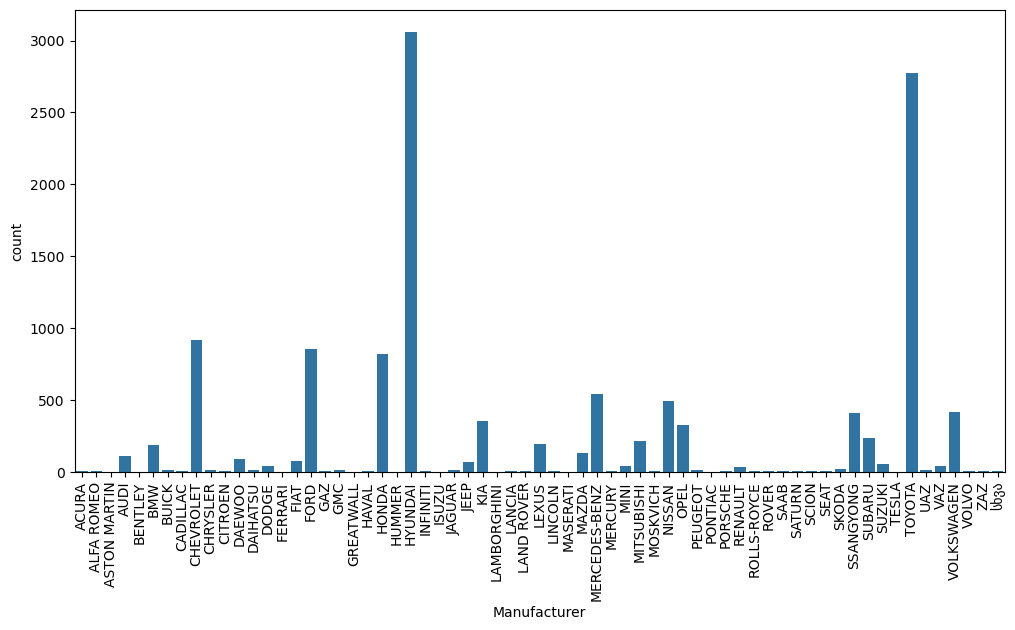

In [39]:
print(df['Manufacturer'].value_counts())
plt.figure(figsize=(12, 6))
### Variable on x-xis and count on y-axis
sns.countplot( x='Manufacturer',  data= df )
plt.xticks(rotation=90)
plt.show()

Prod. year
2014    1546
2012    1517
2013    1509
2011    1066
2015    1051
2016    1030
2010     926
2017     674
2009     373
2008     351
2018     264
2007     251
2005     248
2003     190
2004     175
2006     175
2002     172
2019     164
2000     149
1999     133
2001     131
1998     129
1997     102
1996      69
1995      68
1994      27
1992      18
1990      14
2020      14
1993      13
1988       9
1991       6
1987       5
1984       4
1985       3
1953       3
1983       3
1986       3
1989       3
1964       2
1939       2
1980       2
1977       1
1957       1
1978       1
1981       1
1982       0
1973       0
1968       0
1965       0
1974       0
1976       0
1943       0
1947       0
Name: count, dtype: int64


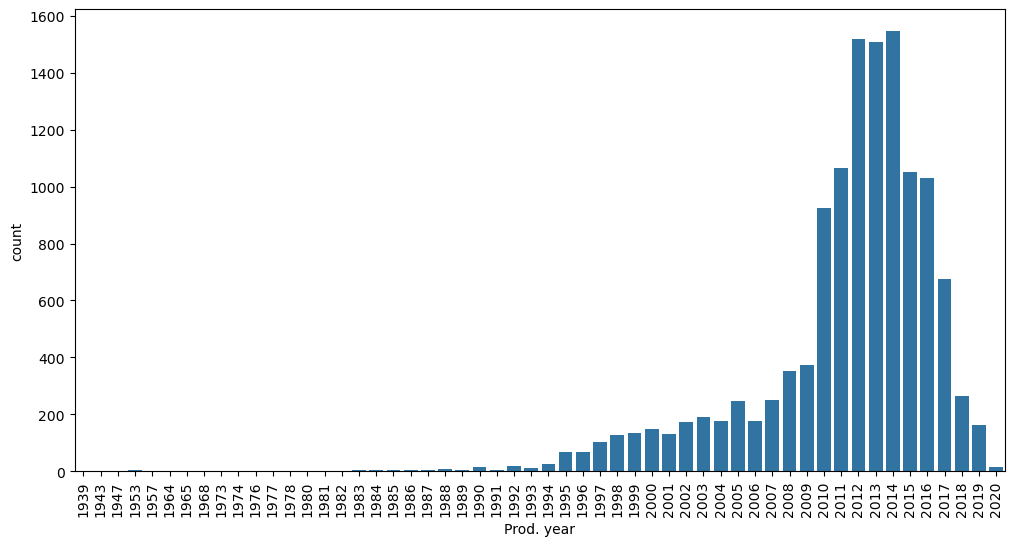

In [40]:
print(df['Prod. year'].value_counts())
### Variable on x-xis and count on y-axis
plt.figure(figsize=(12, 6))
sns.countplot( x='Prod. year',  data= df )

plt.xticks(rotation=90)  # Rotate x-axis labels by 45 degrees
plt.show()

Category
Sedan          5931
Jeep           2713
Hatchback      2530
Minivan         487
Universal       296
Coupe           257
Microbus        176
Goods wagon     174
Pickup           21
Cabriolet        10
Limousine         3
Name: count, dtype: int64


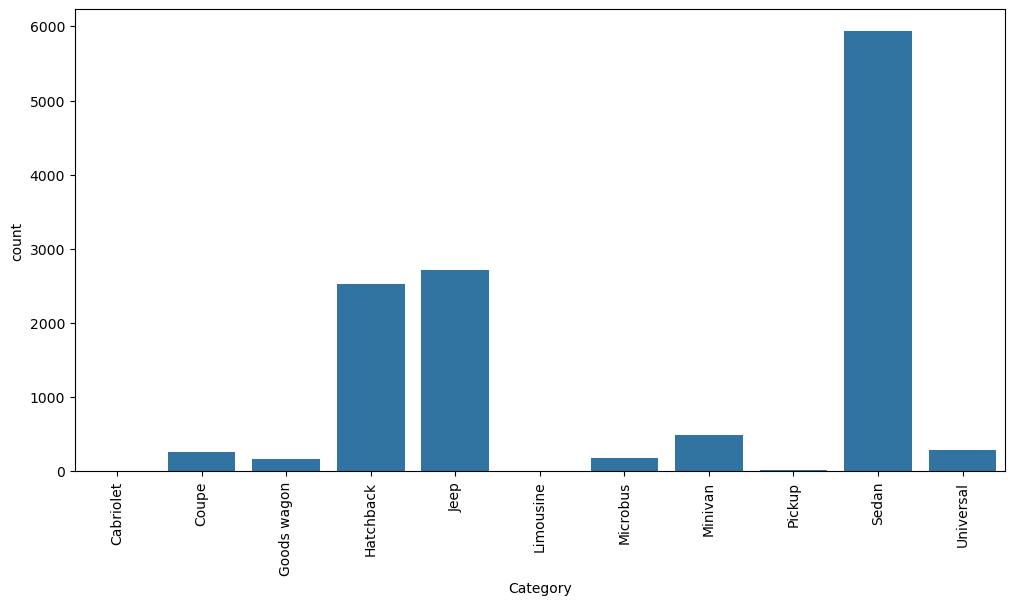

In [41]:
print(df['Category'].value_counts())
plt.figure(figsize=(12, 6))
### Variable on x-xis and count on y-axis
sns.countplot( x='Category',  data= df )
plt.xticks(rotation=90)  # Rotate x-axis labels by 45 degrees
plt.show()

In [42]:
print(df['Leather interior'].value_counts())
### Variable on x-xis and count on y-axis
sns.countplot( x='Leather interior',  data= df )

Leather interior
Yes    8430
No     4168
Name: count, dtype: int64


<Axes: xlabel='Leather interior', ylabel='count'>

In [43]:
print(df['Fuel type'].value_counts())
### Variable on x-xis and count on y-axis
sns.countplot( x='Fuel type',  data= df )

Fuel type
Petrol            6494
Hybrid            2862
Diesel            2423
LPG                484
CNG                254
Plug-in Hybrid      81
Hydrogen             0
Name: count, dtype: int64


<Axes: xlabel='Leather interior', ylabel='count'>

In [44]:
print(df['Gear box type'].value_counts())
### Variable on x-xis and count on y-axis
sns.countplot( x='Gear box type',  data= df )

Gear box type
Automatic    9058
Tiptronic    1567
Manual       1319
Variator      654
Name: count, dtype: int64


<Axes: xlabel='Leather interior', ylabel='count'>

In [45]:
print(df['Drive wheels'].value_counts())
### Variable on x-xis and count on y-axis
sns.countplot( x='Drive wheels',  data= df )

Drive wheels
Front    10614
4x4       1188
Rear       796
Name: count, dtype: int64


<Axes: xlabel='Leather interior', ylabel='count'>

In [46]:
print(df['Wheel'].value_counts())
### Variable on x-xis and count on y-axis
sns.countplot( x='Wheel',  data= df )

Wheel
Left wheel          11487
Right-hand drive     1111
Name: count, dtype: int64


<Axes: xlabel='Leather interior', ylabel='count'>

Color
White            3105
Black            2797
Silver           2664
Grey             1563
Blue              981
Red               526
Green             226
Carnelian red     136
Brown             116
Golden            102
Sky blue          100
Beige              87
Yellow             82
Orange             72
Purple             26
Pink               15
Name: count, dtype: int64


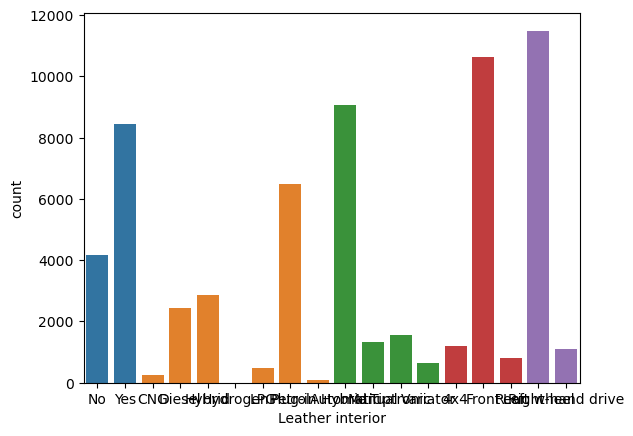

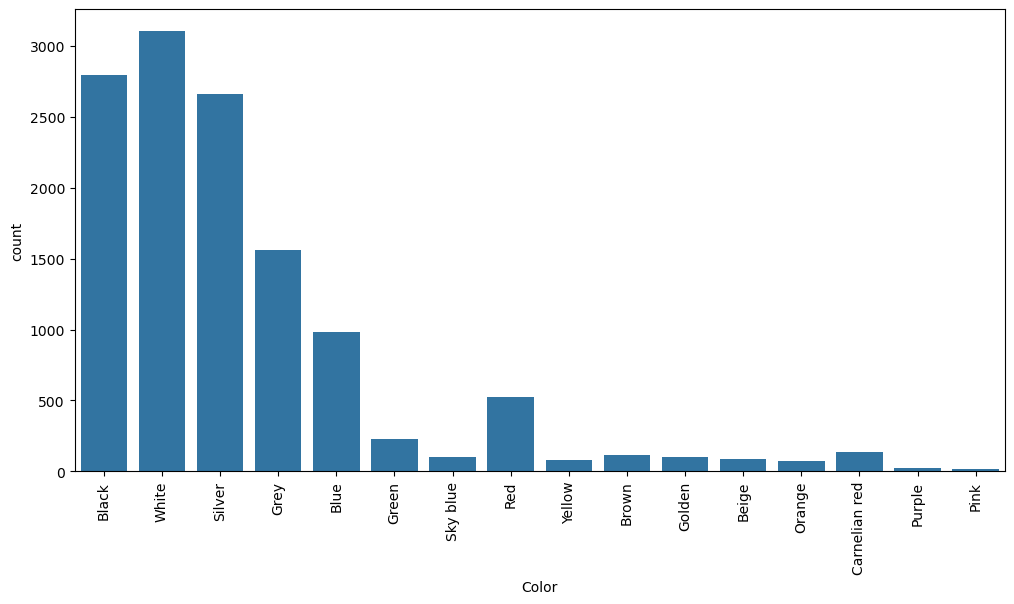

In [47]:
print(df['Color'].value_counts())
plt.figure(figsize=(12, 6))
### Variable on x-xis and count on y-axis
sns.countplot( x='Color',  data= df )
plt.xticks(rotation=90)
plt.show()

## Observation/Conclusion

It is observed from the various countplots plotted on the various categorical features that vehicles that are Hyundai, Sedan, White, left-wheel driven and with leather interior appeared more in the dataset. Also, car models of 2012 and 2014 appeared more.

In addition, vehicles with 4 doors and are front-wheel driven were more popular.

Overeall, all the features are evenly distributed. This will not affect further analysis of the data.

## Section 2d Histogram/Skewness

In [48]:
df.skew(numeric_only=True)

ID              -11.670307
Price             0.787987
Levy              0.815266
Engine volume    -0.398258
Mileage           0.514254
Cylinders         0.000000
Airbags           0.288839
dtype: float64

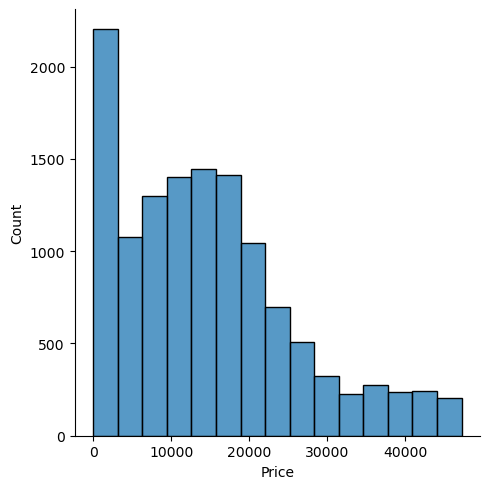

In [49]:
sns.displot(x='Price', data= df, bins=15 )
plt.show()

In [50]:
sns.displot(x='Levy', data= df, bins=15 )

In [51]:
sns.displot(x='Engine volume', data= df, bins=15 )

In [52]:
sns.displot(x='Mileage', data= df)

In [53]:
sns.displot(x='Cylinders', data= df, bins=15 )

In [54]:
sns.displot(x='Airbags', data= df, bins=15 )

## Observation/Conclusion

From the histograms drawn for the features, it could be observed that most of the variables are fairly distributed.
Therefore, there was no need to carry out any data transformation.

## Section 3a Jointplot

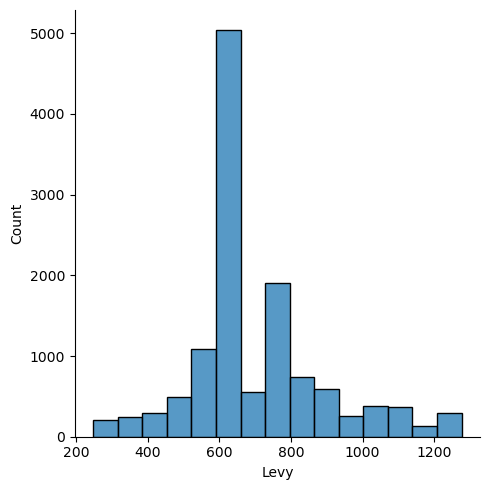

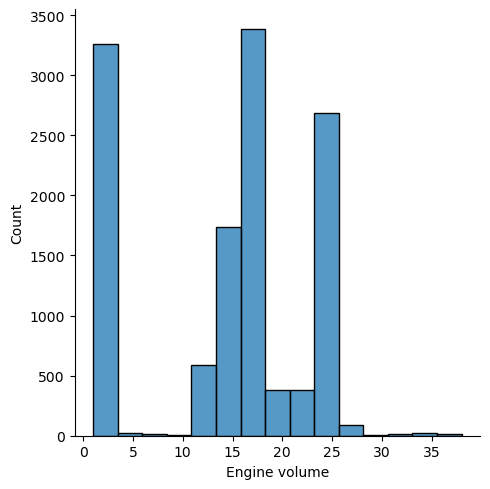

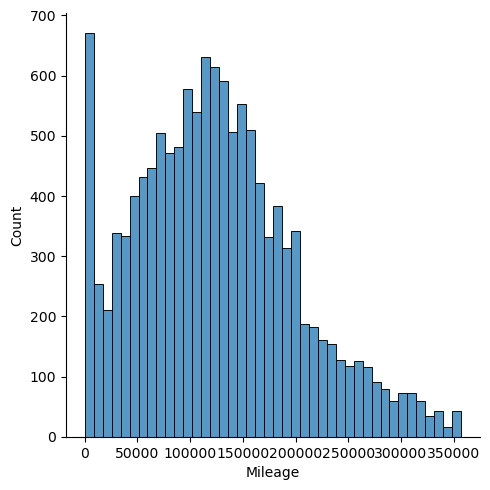

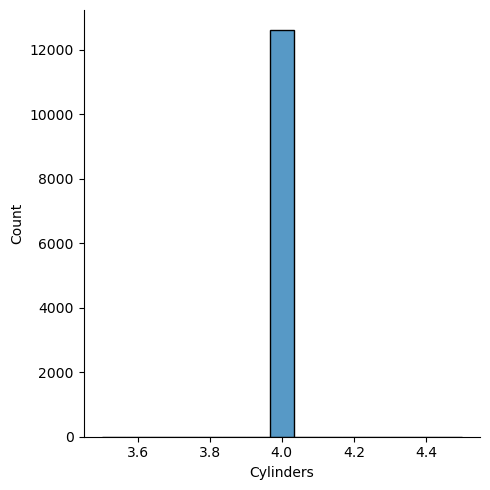

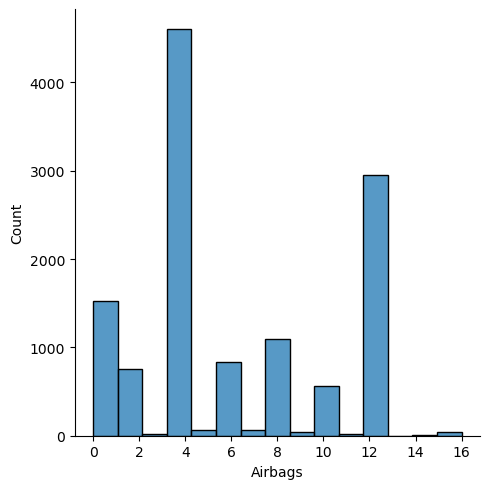

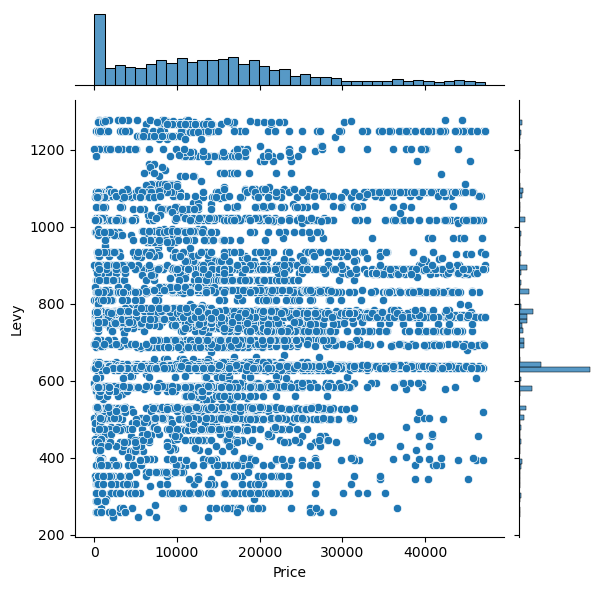

In [55]:
    # Joint Plot @kind are 'hex', 'reg', 'kde'
sns.jointplot(data = df, x= 'Price' , y= 'Levy' , kind = 'scatter') # kind='scatter' default
plt.show()

In [56]:
# Joint Plot @kind are 'hex', 'reg', 'kde'
sns.jointplot(data = df, x= 'Price' , y= 'Engine volume' , kind = 'scatter') # kind='scatter' default

In [57]:
df[['Price', 'Levy']].corr()

,Price,Levy
Price,1.000000,0.145109
Levy,0.145109,1.000000


In [58]:
# Joint Plot @kind are 'hex', 'reg', 'kde'
sns.jointplot(data = df, x= 'Price' , y= 'Mileage' , kind = 'scatter') # kind='scatter' default

In [59]:
# Joint Plot @kind are 'hex', 'reg', 'kde'
#Airbags
sns.jointplot(data = df, x= 'Price' , y= 'Cylinders' , kind = 'scatter') # kind='scatter' default

In [60]:
df.dtypes

ID                     int64
Price                  int64
Levy                 float64
Manufacturer        category
Model               category
Prod. year          category
Category            category
Leather interior    category
Fuel type           category
Engine volume        float64
Mileage                int64
Cylinders            float64
Gear box type       category
Drive wheels        category
Doors               category
Wheel               category
Color                 object
Airbags                int64
dtype: object

In [61]:
# Joint Plot @kind are 'hex', 'reg', 'kde'
sns.jointplot(data = df, x= 'Price' , y= 'Airbags' , kind = 'scatter') # kind='scatter' default

## Observation/Conclusion

After ploting jointplots for each variable it is observed that only 'Cylinder' has perfect linear relationship with the dependent variable(Price). Other features seem to have points scattered on the graph without any definite pattern. This shows weak relationships with the dependent variable.


# Section 3c Feature Encoding

In [62]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [63]:
df.dtypes

ID                     int64
Price                  int64
Levy                 float64
Manufacturer        category
Model               category
Prod. year          category
Category            category
Leather interior    category
Fuel type           category
Engine volume        float64
Mileage                int64
Cylinders            float64
Gear box type       category
Drive wheels        category
Doors               category
Wheel               category
Color                 object
Airbags                int64
dtype: object

In [64]:
print(df['Manufacturer'].unique())
#This prints all unique manufacturer names in the dataset.

Manufacturer1 = LabelEncoder()
print(df['Manufacturer'])
#Creates an instance of LabelEncoder.
#Prints the original 'Manufacturer' column (categorical values).

Manufacturer1 = Manufacturer1.fit(df['Manufacturer']) ### Mapping Table created
#Fitting the LabelEncoder creates a mapping table (each unique category is assigned a number).

rec_values = Manufacturer1.transform(df['Manufacturer'])
df['Manufacturer'] = rec_values
#Transforming: Converts category names into numeric values.
#Assigns the transformed values back to the DataFrame.

print(df['Manufacturer'])
#Prints the updated 'Manufacturer' column (now with numbers instead of names).
print(Manufacturer1.classes_)

['HONDA', 'FORD', 'HYUNDAI', 'TOYOTA', 'OPEL', ..., 'MOSKVICH', 'VOLVO', 'SATURN', 'ZAZ', 'ROLLS-ROYCE']
Length: 55
Categories (65, object): ['ACURA', 'ALFA ROMEO', 'ASTON MARTIN', 'AUDI', ..., 'VOLKSWAGEN', 'VOLVO', 'ZAZ', 'სხვა']
2                HONDA
3                 FORD
4                HONDA
5              HYUNDAI
6               TOYOTA
             ...      
19230           TOYOTA
19232    MERCEDES-BENZ
19233          HYUNDAI
19234          HYUNDAI
19236          HYUNDAI
Name: Manufacturer, Length: 12598, dtype: category
Categories (65, object): ['ACURA', 'ALFA ROMEO', 'ASTON MARTIN', 'AUDI', ..., 'VOLKSWAGEN', 'VOLVO', 'ZAZ', 'სხვა']
2        17
3        13
4        17
5        18
6        48
         ..
19230    48
19232    28
19233    18
19234    18
19236    18
Name: Manufacturer, Length: 12598, dtype: int64
['ACURA' 'ALFA ROMEO' 'AUDI' 'BMW' 'BUICK' 'CADILLAC' 'CHEVROLET'
 'CHRYSLER' 'CITROEN' 'DAEWOO' 'DAIHATSU' 'DODGE' 'FIAT' 'FORD' 'GAZ'
 'GMC' 'HAVAL' 'HONDA' 'HYUNDAI'

In [65]:
print(df['Model'].unique())

Model1 = LabelEncoder()
print(df['Model'])

Model1 = Model1.fit(df['Model']) ### Mapping Table created
rec_values = Model1.transform(df['Model'])
df['Model'] = rec_values

print(df['Model'])

print(Model1.classes_)

['FIT', 'Escape', 'Santa FE', 'Prius', 'Sonata', ..., '20', '406', 'E 230 124', 'CLA 250 AMG', 'Optima ex']
Length: 989
Categories (1590, object): ['09-Mar', '100', '100 NX', '1000', ..., 'macan', 'macan S', 'tC', 'xD']
2             FIT
3          Escape
4             FIT
5        Santa FE
6           Prius
           ...   
19230       Prius
19232     CLK 200
19233      Sonata
19234      Tucson
19236      Sonata
Name: Model, Length: 12598, dtype: category
Categories (1590, object): ['09-Mar', '100', '100 NX', '1000', ..., 'macan', 'macan S', 'tC', 'xD']
2        421
3        406
4        421
5        795
6        724
        ... 
19230    724
19232    222
19233    816
19234    900
19236    816
Name: Model, Length: 12598, dtype: int64
['09-Mar' '100 NX' '1000' '1111' '114' '118' '118 2,0' '118 M-sport LCI'
 '120' '1300' '147' '1500' '159' '190' '20' '200' '206' '206 CC' '207'
 '21' '2101 01' '2103 03' '2105' '2106' '2107' '2107 07' '2109' '2111'
 '2121 (Niva)' '216' '220' '230' '24 10

In [66]:
print(df['Prod. year'].unique())

Prodyear1 = LabelEncoder()
print(df['Prod. year'])

Prodyear1 = Prodyear1.fit(df['Prod. year']) ### Mapping Table created
rec_values = Prodyear1.transform(df['Prod. year'])
df['Prod. year'] = rec_values

print(df['Prod. year'])

print(Prodyear1.classes_)

[2006, 2011, 2014, 2016, 2010, ..., 1980, 1939, 1978, 1981, 1977]
Length: 46
Categories (54, int64): [1939, 1943, 1947, 1953, ..., 2017, 2018, 2019, 2020]
2        2006
3        2011
4        2014
5        2016
6        2010
         ... 
19230    2011
19232    1999
19233    2011
19234    2010
19236    2012
Name: Prod. year, Length: 12598, dtype: category
Categories (54, int64): [1939, 1943, 1947, 1953, ..., 2017, 2018, 2019, 2020]
2        31
3        36
4        39
5        41
6        35
         ..
19230    36
19232    24
19233    36
19234    35
19236    37
Name: Prod. year, Length: 12598, dtype: int64
[1939 1953 1957 1964 1977 1978 1980 1981 1983 1984 1985 1986 1987 1988
 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002
 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016
 2017 2018 2019 2020]


In [67]:
print(df['Category'].unique())

Category1 = LabelEncoder()
print(df['Category'])

Category1 = Category1.fit(df['Category']) ### Mapping Table created
rec_values = Category1.transform(df['Category'])
df['Category'] = rec_values
print(df['Category'])

print(Category1.classes_)

['Hatchback', 'Jeep', 'Sedan', 'Goods wagon', 'Microbus', ..., 'Coupe', 'Minivan', 'Cabriolet', 'Pickup', 'Limousine']
Length: 11
Categories (11, object): ['Cabriolet', 'Coupe', 'Goods wagon', 'Hatchback', ..., 'Minivan', 'Pickup', 'Sedan', 'Universal']
2        Hatchback
3             Jeep
4        Hatchback
5             Jeep
6        Hatchback
           ...    
19230    Hatchback
19232        Coupe
19233        Sedan
19234         Jeep
19236        Sedan
Name: Category, Length: 12598, dtype: category
Categories (11, object): ['Cabriolet', 'Coupe', 'Goods wagon', 'Hatchback', ..., 'Minivan', 'Pickup', 'Sedan', 'Universal']
2        3
3        4
4        3
5        4
6        3
        ..
19230    3
19232    1
19233    9
19234    4
19236    9
Name: Category, Length: 12598, dtype: int64
['Cabriolet' 'Coupe' 'Goods wagon' 'Hatchback' 'Jeep' 'Limousine'
 'Microbus' 'Minivan' 'Pickup' 'Sedan' 'Universal']


In [68]:
print(df['Leather interior'].unique())

Leather = LabelEncoder()
print(df['Leather interior'])

Leather = Leather.fit(df['Leather interior']) ### Mapping Table created
rec_values = Leather.transform(df['Leather interior'])
df['Leather interior'] = rec_values

print(df['Leather interior'])

print(Leather.classes_)

['No', 'Yes']
Categories (2, object): ['No', 'Yes']
2         No
3        Yes
4        Yes
5        Yes
6        Yes
        ... 
19230    Yes
19232    Yes
19233    Yes
19234    Yes
19236    Yes
Name: Leather interior, Length: 12598, dtype: category
Categories (2, object): ['No', 'Yes']
2        0
3        1
4        1
5        1
6        1
        ..
19230    1
19232    1
19233    1
19234    1
19236    1
Name: Leather interior, Length: 12598, dtype: int64
['No' 'Yes']


In [69]:
print(df['Fuel type'].unique())

Fuel = LabelEncoder()
print(df['Fuel type'])

Fuel = Fuel.fit(df['Fuel type']) ### Mapping Table created
rec_values = Fuel.transform(df['Fuel type'])
df['Fuel type'] = rec_values

print(df['Fuel type'])

print(Fuel.classes_)

['Petrol', 'Hybrid', 'Diesel', 'CNG', 'Plug-in Hybrid', 'LPG']
Categories (7, object): ['CNG', 'Diesel', 'Hybrid', 'Hydrogen', 'LPG', 'Petrol', 'Plug-in Hybrid']
2        Petrol
3        Hybrid
4        Petrol
5        Diesel
6        Hybrid
          ...  
19230    Hybrid
19232       CNG
19233    Petrol
19234    Diesel
19236    Hybrid
Name: Fuel type, Length: 12598, dtype: category
Categories (7, object): ['CNG', 'Diesel', 'Hybrid', 'Hydrogen', 'LPG', 'Petrol', 'Plug-in Hybrid']
2        4
3        2
4        4
5        1
6        2
        ..
19230    2
19232    0
19233    4
19234    1
19236    2
Name: Fuel type, Length: 12598, dtype: int64
['CNG' 'Diesel' 'Hybrid' 'LPG' 'Petrol' 'Plug-in Hybrid']


In [70]:
print(df['Gear box type'].unique())

Gear = LabelEncoder()
print(df['Gear box type'])

Gear = Fuel.fit(df['Gear box type']) ### Mapping Table created
rec_values = Gear.transform(df['Gear box type'])
df['Gear box type'] = rec_values

print(df['Gear box type'])

print(Gear.classes_)

['Variator', 'Automatic', 'Manual', 'Tiptronic']
Categories (4, object): ['Automatic', 'Manual', 'Tiptronic', 'Variator']
2         Variator
3        Automatic
4        Automatic
5        Automatic
6        Automatic
           ...    
19230    Automatic
19232       Manual
19233    Tiptronic
19234    Automatic
19236    Automatic
Name: Gear box type, Length: 12598, dtype: category
Categories (4, object): ['Automatic', 'Manual', 'Tiptronic', 'Variator']
2        3
3        0
4        0
5        0
6        0
        ..
19230    0
19232    1
19233    2
19234    0
19236    0
Name: Gear box type, Length: 12598, dtype: int64
['Automatic' 'Manual' 'Tiptronic' 'Variator']


In [71]:
print(df['Doors'].unique())

Door = LabelEncoder()
print(df['Doors'])

Door = Door.fit(df['Doors']) ### Mapping Table created
rec_values = Door.transform(df['Doors'])
df['Doors'] = rec_values

print(df['Doors'])

print(Door.classes_)

['04-May', '02-Mar', '>5']
Categories (3, object): ['02-Mar', '04-May', '>5']
2        04-May
3        04-May
4        04-May
5        04-May
6        04-May
          ...  
19230    04-May
19232    02-Mar
19233    04-May
19234    04-May
19236    04-May
Name: Doors, Length: 12598, dtype: category
Categories (3, object): ['02-Mar', '04-May', '>5']
2        1
3        1
4        1
5        1
6        1
        ..
19230    1
19232    0
19233    1
19234    1
19236    1
Name: Doors, Length: 12598, dtype: int64
['02-Mar' '04-May' '>5']


In [72]:
print(df['Color'].unique())

Colors = LabelEncoder()
print(df['Color'])

Colors = Colors.fit(df['Color']) ### Mapping Table created
rec_values = Colors.transform(df['Color'])
df['Color'] = rec_values

print(df['Color'])

print(Colors.classes_)

['Black' 'White' 'Silver' 'Grey' 'Blue' 'Green' 'Sky blue' 'Red' 'Yellow'
 'Brown' 'Golden' 'Beige' 'Orange' 'Carnelian red' 'Purple' 'Pink']
2         Black
3         White
4        Silver
5         White
6         White
          ...  
19230    Silver
19232    Silver
19233       Red
19234      Grey
19236     White
Name: Color, Length: 12598, dtype: object
2         1
3        14
4        12
5        14
6        14
         ..
19230    12
19232    12
19233    11
19234     7
19236    14
Name: Color, Length: 12598, dtype: int64
['Beige' 'Black' 'Blue' 'Brown' 'Carnelian red' 'Golden' 'Green' 'Grey'
 'Orange' 'Pink' 'Purple' 'Red' 'Silver' 'Sky blue' 'White' 'Yellow']


In [73]:
print(df['Drive wheels'].unique())

Wheels = LabelEncoder()
print(df['Drive wheels'])

Wheels = Wheels.fit(df['Drive wheels']) ### Mapping Table created
rec_values = Wheels.transform(df['Drive wheels'])
df['Drive wheels'] = rec_values

print(df['Drive wheels'])

print(Wheels.classes_)

['Front', '4x4', 'Rear']
Categories (3, object): ['4x4', 'Front', 'Rear']
2        Front
3          4x4
4        Front
5        Front
6        Front
         ...  
19230    Front
19232     Rear
19233    Front
19234    Front
19236    Front
Name: Drive wheels, Length: 12598, dtype: category
Categories (3, object): ['4x4', 'Front', 'Rear']
2        1
3        0
4        1
5        1
6        1
        ..
19230    1
19232    2
19233    1
19234    1
19236    1
Name: Drive wheels, Length: 12598, dtype: int64
['4x4' 'Front' 'Rear']


In [74]:
print(df['Wheel'].unique())

Wheel1 = LabelEncoder()
print(df['Wheel'])

Wheel1 = Wheel1.fit(df['Wheel']) ### Mapping Table created
rec_values = Wheel1.transform(df['Wheel'])
df['Wheel'] = rec_values

print(df['Wheel'])

print(Wheel1.classes_)

['Right-hand drive', 'Left wheel']
Categories (2, object): ['Left wheel', 'Right-hand drive']
2        Right-hand drive
3              Left wheel
4              Left wheel
5              Left wheel
6              Left wheel
               ...       
19230          Left wheel
19232          Left wheel
19233          Left wheel
19234          Left wheel
19236          Left wheel
Name: Wheel, Length: 12598, dtype: category
Categories (2, object): ['Left wheel', 'Right-hand drive']
2        1
3        0
4        0
5        0
6        0
        ..
19230    0
19232    0
19233    0
19234    0
19236    0
Name: Wheel, Length: 12598, dtype: int64
['Left wheel' 'Right-hand drive']


In [75]:
df.dtypes

ID                    int64
Price                 int64
Levy                float64
Manufacturer          int64
Model                 int64
Prod. year            int64
Category              int64
Leather interior      int64
Fuel type             int64
Engine volume       float64
Mileage               int64
Cylinders           float64
Gear box type         int64
Drive wheels          int64
Doors                 int64
Wheel                 int64
Color                 int64
Airbags               int64
dtype: object

## Observation/Conclusion

In this section, it is observed that the following features are all categorical:
Manufacturer        category
Model               category
Prod. year          category
Category            category
Leather interior    category
Fuel type           category
Gear box type       category
Drive wheels        category
Doors               category
Wheel               category
Color                 object

Therefore, they were all converted to numerical values using the LabelEncoder method.

# Section 3b feature scaling

In [76]:
# Initialize the Min-Max scaler
scaler = MinMaxScaler()
#Creates an instance of MinMaxScaler (by default, it scales values between 0 and 1).

# Fit the scaler to your data and transform it
scaled_data = scaler.fit_transform(df)
#fit(df): Computes the min and max values for each column.
#transform(df): Applies the scaling transformation to the data.
#The result is stored in scaled_data (which will be an array, not a DataFrame).
print(scaled_data)

[[0.9983153  0.17930363 0.3746283  ... 1.         0.06666667 0.125     ]
 [0.99810652 0.07637242 0.59708738 ... 0.         0.93333333 0.        ]
 [0.99970518 0.24832684 0.19320388 ... 0.         0.8        0.25      ]
 ...
 [0.99849229 0.33209082 0.56699029 ... 0.         0.73333333 0.5       ]
 [0.99953502 0.55292697 0.57184466 ... 0.         0.46666667 0.25      ]
 [0.99986514 0.00993307 0.49126214 ... 0.         0.93333333 0.75      ]]


In [77]:
# Create a DataFrame with the scaled data
scaled_df = pd.DataFrame(data=scaled_data, columns=df.columns)

# Display the scaled DataFrame
print(scaled_df)

             ID     Price      Levy  Manufacturer     Model  Prod. year  \
0      0.998315  0.179304  0.374628      0.314815  0.426113    0.688889   
1      0.998107  0.076372  0.597087      0.240741  0.410931    0.800000   
2      0.999705  0.248327  0.193204      0.314815  0.426113    0.866667   
3      0.999452  0.836411  0.625243      0.333333  0.804656    0.911111   
4      0.993622  0.038165  0.499029      0.888889  0.732794    0.777778   
...         ...       ...       ...           ...       ...         ...   
12593  0.997776  0.009933  0.386408      0.888889  0.732794    0.800000   
12594  0.999270  0.179304  0.374628      0.518519  0.224696    0.533333   
12595  0.998492  0.332091  0.566990      0.333333  0.825911    0.800000   
12596  0.999535  0.552927  0.571845      0.333333  0.910931    0.777778   
12597  0.999865  0.009933  0.491262      0.333333  0.825911    0.822222   

       Category  Leather interior  Fuel type  Engine volume   Mileage  \
0           0.3           

In [78]:
scaled_df

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,0.998315,0.179304,0.374628,0.314815,0.426113,0.688889,0.3,0.0,0.8,0.324324,0.559989,0.0,1.000000,0.5,0.5,1.0,0.066667,0.1250
1,0.998107,0.076372,0.597087,0.240741,0.410931,0.800000,0.4,1.0,0.4,0.648649,0.473095,0.0,0.000000,0.0,0.5,0.0,0.933333,0.0000
2,0.999705,0.248327,0.193204,0.314815,0.426113,0.866667,0.3,1.0,0.8,0.324324,0.257318,0.0,0.000000,0.5,0.5,0.0,0.800000,0.2500
3,0.999452,0.836411,0.625243,0.333333,0.804656,0.911111,0.4,1.0,0.2,0.027027,0.450598,0.0,0.000000,0.5,0.5,0.0,0.933333,0.2500
4,0.993622,0.038165,0.499029,0.888889,0.732794,0.777778,0.3,1.0,0.4,0.459459,0.724931,0.0,0.000000,0.5,0.5,0.0,0.933333,0.7500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12593,0.997776,0.009933,0.386408,0.888889,0.732794,0.800000,0.3,1.0,0.4,0.459459,0.860493,0.0,0.000000,0.5,0.5,0.0,0.800000,0.7500
12594,0.999270,0.179304,0.374628,0.518519,0.224696,0.533333,0.1,1.0,0.0,0.513514,0.839983,0.0,0.333333,1.0,0.0,0.0,0.800000,0.3125
12595,0.998492,0.332091,0.566990,0.333333,0.825911,0.800000,0.9,1.0,0.8,0.621622,0.452471,0.0,0.666667,0.5,0.5,0.0,0.733333,0.5000
12596,0.999535,0.552927,0.571845,0.333333,0.910931,0.777778,0.4,1.0,0.2,0.027027,0.325815,0.0,0.000000,0.5,0.5,0.0,0.466667,0.2500


# Observation/Conclusion

In this section feature scaling was carried out using the Min-Max Scaler method. Our dataframe(df) was transformed using the scaler.fit_transform() method. And a new dataframe was created with the name Scaled_df.

From the Scale_df table shown above, it can be observed that all variables had been transformed based on equal parameters using the Min-Max Scaler method.

# Section 3d,Correlation Heatmap (Multicollinearity checking)

In [79]:
## y is dependent variable and X is set of independent variables.
y = df['Price']
#This extracts the Price column from df and stores it in y.
#The .shape function prints the number of rows (data points) in y.
 # Load X Variables into a Pandas Dataframe with columns
X = df.drop(['Price'], axis = 1)
print(y.shape)
print(X.shape)

(12598,)
(12598, 17)


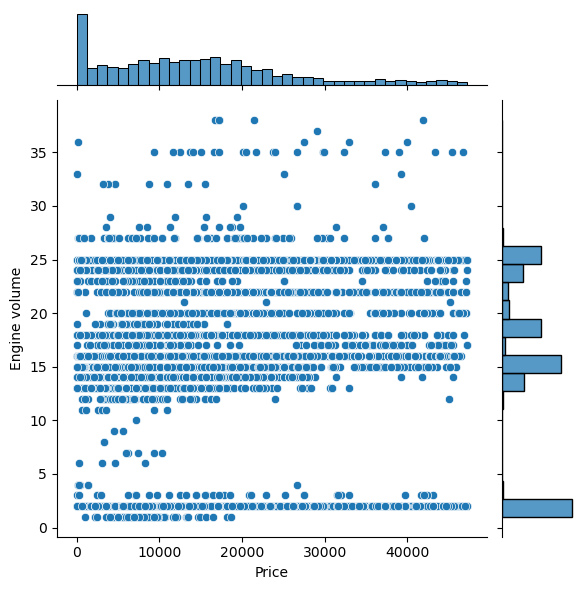

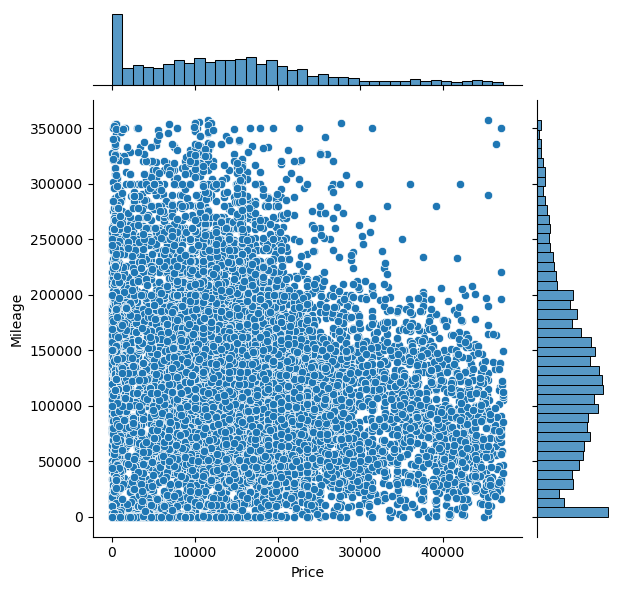

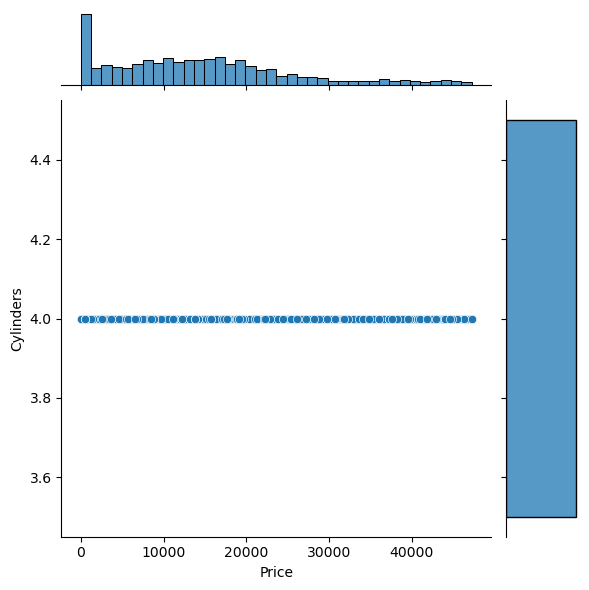

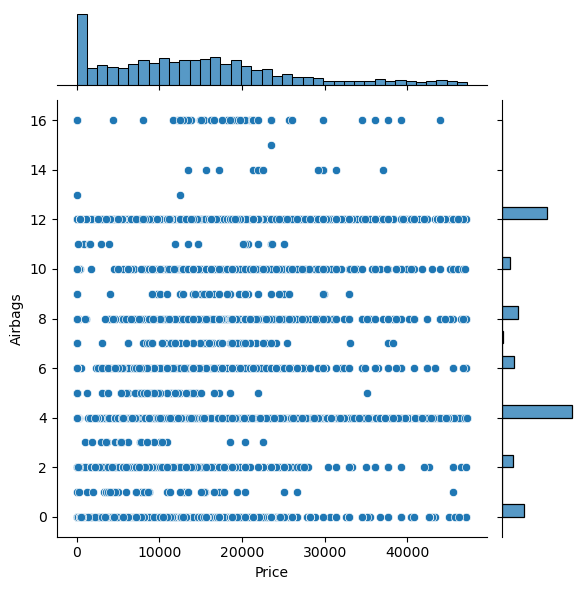

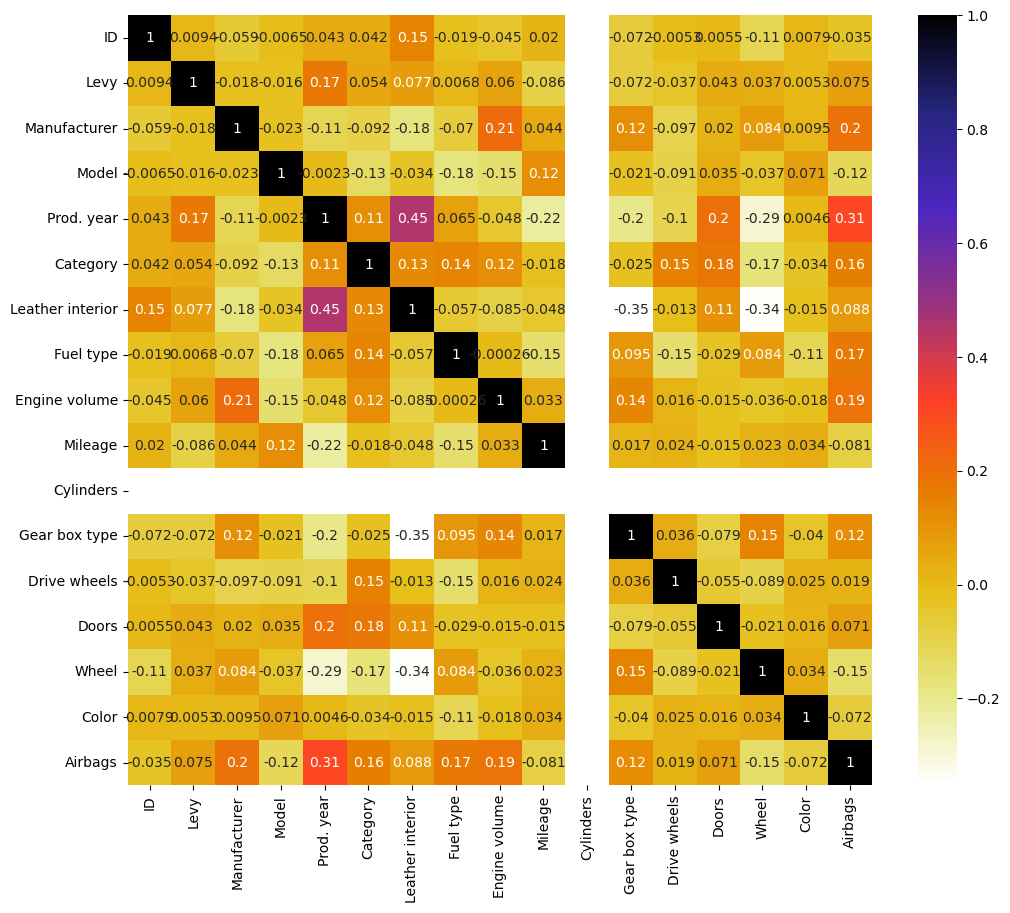

In [80]:
corr_matrix = X.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap=plt.cm.CMRmap_r,annot=True)
#Applies a color map (CMRmap_r gives a reversed color scale).
#annot=True → Displays numerical correlation values inside the heatmap cells.
plt.show()

In [81]:
corr_matrix

,ID,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
ID,1.000000,0.009368,-0.058790,-0.006521,0.042845,0.042331,0.145837,-0.018794,-0.045326,0.020018,NaN,-0.072361,-0.005350,0.005529,-0.105382,0.007903,-0.034692
Levy,0.009368,1.000000,-0.017804,-0.016156,0.173201,0.053774,0.077108,0.006804,0.060348,-0.085742,NaN,-0.071863,-0.037098,0.042690,0.036811,0.005273,0.074940
Manufacturer,-0.058790,-0.017804,1.000000,-0.022721,-0.105834,-0.091851,-0.177842,-0.069585,0.210799,0.044128,NaN,0.115425,-0.097382,0.019629,0.084034,0.009486,0.196593
Model,-0.006521,-0.016156,-0.022721,1.000000,-0.002283,-0.134775,-0.033644,-0.177431,-0.149279,0.116470,NaN,-0.021331,-0.090733,0.034984,-0.037380,0.071270,-0.116910
Prod. year,0.042845,0.173201,-0.105834,-0.002283,1.000000,0.113676,0.454363,0.065389,-0.047839,-0.222458,NaN,-0.199297,-0.101631,0.199674,-0.286472,0.004581,0.307601
Category,0.042331,0.053774,-0.091851,-0.134775,0.113676,1.000000,0.130868,0.139292,0.117484,-0.018386,NaN,-0.025063,0.151405,0.180727,-0.168055,-0.033757,0.157498
Leather interior,0.145837,0.077108,-0.177842,-0.033644,0.454363,0.130868,1.000000,-0.056589,-0.084600,-0.048124,NaN,-0.352670,-0.012661,0.111562,-0.343529,-0.014633,0.088338
Fuel type,-0.018794,0.006804,-0.069585,-0.177431,0.065389,0.139292,-0.056589,1.000000,-0.000260,-0.150459,NaN,0.094852,-0.149867,-0.029209,0.083548,-0.106070,0.174833
Engine volume,-0.045326,0.060348,0.210799,-0.149279,-0.047839,0.117484,-0.084600,-0.000260,1.000000,0.033245,NaN,0.137340,0.016460,-0.015049,-0.036165,-0.018188,0.190521
Mileage,0.020018,-0.085742,0.044128,0.116470,-0.222458,-0.018386,-0.048124,-0.150459,0.033245,1.000000,NaN,0.016972,0.024341,-0.015190,0.022760,0.034256,-0.080744


# Observations/Cnclusion

To test correlations among the independent variables, I first of all separated independent variables(X) from the dependent variable (y).

It is observed that after carrying out the correlation test among the independent variables all, the heatmap indicates that there is no correlation among them. Therefore, no correlation value is above 0.7 threshhold given.

In conclusion, the features show no autocorrelation among themselves, which makes our data fit for further analysis.


# Section 4 Feature selection using correlation with the MSRP

In [82]:
corr_with_target = X.corrwith(y)
corr_with_target

C:\Users\Bra E\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Bra E\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


ID                  0.023679
Levy                0.145109
Manufacturer       -0.073704
Model               0.088962
Prod. year          0.333140
Category           -0.064244
Leather interior    0.121344
Fuel type          -0.184177
Engine volume      -0.022063
Mileage            -0.169998
Cylinders                NaN
Gear box type       0.054276
Drive wheels        0.028759
Doors               0.052161
Wheel              -0.178885
Color               0.037757
Airbags            -0.071581
dtype: float64

In [83]:
top_features = corr_with_target.abs().sort_values(ascending=False).head(7)

In [84]:
selected_features = scaled_df[top_features.index]

In [85]:
print(selected_features)

       Prod. year  Fuel type  Wheel   Mileage      Levy  Leather interior  \
0        0.688889        0.8    1.0  0.559989  0.374628               0.0   
1        0.800000        0.4    0.0  0.473095  0.597087               1.0   
2        0.866667        0.8    0.0  0.257318  0.193204               1.0   
3        0.911111        0.2    0.0  0.450598  0.625243               1.0   
4        0.777778        0.4    0.0  0.724931  0.499029               1.0   
...           ...        ...    ...       ...       ...               ...   
12593    0.800000        0.4    0.0  0.860493  0.386408               1.0   
12594    0.533333        0.0    0.0  0.839983  0.374628               1.0   
12595    0.800000        0.8    0.0  0.452471  0.566990               1.0   
12596    0.777778        0.2    0.0  0.325815  0.571845               1.0   
12597    0.822222        0.4    0.0  0.523374  0.491262               1.0   

          Model  
0      0.426113  
1      0.410931  
2      0.426113  
3  

## Observations & Conclusion — Section 4 (Final Conclusion)
## Observations:
Using corrwith(), the following 7 features were identified as most correlated with Price:

Rank	Feature	Correlation Direction
1	Levy	Positive
2	Prod. year	Positive
3	Fuel type	Varies
4	Mileage	Negative
5	Model	Varies
6	Wheel	Varies
7	Leather interior	Positive
## Final Conclusion:
The data has been fully cleaned, encoded, scaled, and analysed. The 7 selected features (Levy, Prod. year, Fuel type, Mileage, Model, Wheel, Leather interior) represent the strongest predictors of car price in this dataset and will be used as inputs to the machine learning model in the next stage of the capstone project.

